# Inference Batch — Nov/Dec Season Only
Scans **only November and December** JP2 files from each year folder.
This removes seasonal vegetation/cloud bias for fair year-on-year comparison.

**Only update `DATA_ROOT` in Cell 2 — everything else is ready to run.**

## Cell 1 — Imports

In [1]:
import os, glob, re, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torchvision import transforms, models

try:
    import rasterio
    from rasterio.enums import Resampling
    HAS_RASTERIO = True
    print('rasterio OK')
except ImportError:
    HAS_RASTERIO = False
    print('rasterio not found — run: pip install rasterio')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))

rasterio OK
Device: cuda
GPU   : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 — Config

In [2]:
# ── ONLY CHANGE THIS ──────────────────────────────────────────────────────
DATA_ROOT = r"R:\ai project image\data image big"
# ─────────────────────────────────────────────────────────────────────────

YEAR_MAP = {
    'big 2021' : 2021,
    '2022'     : 2022,
    '2023'     : 2023,
    '2024'     : 2024,
    '2025'     : 2025,
}

MODEL_PATH   = 'saved_models/best_model.pth'
NUM_CLASSES  = 2
PATCH_SIZE   = 64
STRIDE       = 32
THRESHOLD    = 0.6
BATCH_SIZE   = 64
NATIVE_RES_M = 10.0   # Sentinel-2 10m/px
MAX_DIM      = 5000
OUTPUT_DIR   = 'inference_output/temporal'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Data root : {DATA_ROOT}')
print(f'Model     : {MODEL_PATH}')
print(f'Output    : {OUTPUT_DIR}')
print(f'Threshold : {THRESHOLD}  |  Patch: {PATCH_SIZE}px  Stride: {STRIDE}px')
print()

# Show which Nov/Dec files will be scanned
print('Nov/Dec files that will be processed:')
for folder, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    folder_path = os.path.join(DATA_ROOT, folder)
    all_files   = sorted(glob.glob(os.path.join(folder_path, '*.jp2')))
    nov_dec     = [f for f in all_files
                   if (m := re.search(r'_(\d{8})T', os.path.basename(f)))
                   and m.group(1)[4:6] in ('11', '12')]
    if nov_dec:
        for f in nov_dec:
            print(f'  {year}: {os.path.basename(f)}')
    else:
        # fallback: show closest month available
        print(f'  {year}: no Nov/Dec found — will use closest available month')

Data root : R:\ai project image\data image big
Model     : saved_models/best_model.pth
Output    : inference_output/temporal
Threshold : 0.6  |  Patch: 64px  Stride: 32px

Nov/Dec files that will be processed:
  2021: T45QUE_20211123T045121_TCI_10m.jp2
  2021: T45QUE_20211223T045221_TCI_10m.jp2
  2022: T45QUE_20221128T045131_TCI_10m.jp2
  2023: T45QUE_20231123T045111_TCI_10m.jp2
  2024: T45QUE_20241207T045201_TCI_10m.jp2
  2025: T45QUE_20251114T045231_TCI_10m.jp2
  2025: T45QUE_20251224T045241_TCI_10m.jp2


## Cell 3 — Load Model

In [3]:
def load_efficientnet_b0(model_path):
    model = models.efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_f, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.4),
        nn.Linear(256, NUM_CLASSES)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    print(f'Model loaded: {model_path}')
    return model

model = load_efficientnet_b0(MODEL_PATH)

patch_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print('Ready.')

Model loaded: saved_models/best_model.pth
Ready.


## Cell 4 — Core Functions

In [4]:
def load_jp2(path):
    if HAS_RASTERIO:
        with rasterio.open(path) as src:
            h, w  = src.height, src.width
            scale = min(1.0, MAX_DIM / max(h, w))
            nh, nw = int(h * scale), int(w * scale)
            data  = src.read(out_shape=(src.count, nh, nw),
                             resampling=Resampling.bilinear)
        data = np.moveaxis(data[:3], 0, -1).astype(np.float32)
        for i in range(3):
            p2, p98 = np.percentile(data[:,:,i], (2, 98))
            data[:,:,i] = np.clip((data[:,:,i]-p2)/(p98-p2+1e-8), 0, 1)
        return (data*255).astype(np.uint8), scale
    else:
        img = Image.open(path).convert('RGB')
        img.thumbnail((MAX_DIM, MAX_DIM))
        arr = np.array(img)
        scale = MAX_DIM / max(arr.shape[:2])
        return arr, scale


def run_inference(img_rgb):
    H, W = img_rgb.shape[:2]
    prob_map  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    detections = []

    positions = [(y, x)
                 for y in range(0, H - PATCH_SIZE + 1, STRIDE)
                 for x in range(0, W - PATCH_SIZE + 1, STRIDE)]

    buf_patches, buf_pos = [], []
    with torch.no_grad():
        for i, (y, x) in enumerate(positions):
            patch = img_rgb[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
            buf_patches.append(patch_transform(Image.fromarray(patch)))
            buf_pos.append((y, x))

            if len(buf_patches) == BATCH_SIZE or i == len(positions)-1:
                batch = torch.stack(buf_patches).to(device)
                probs = torch.softmax(model(batch), dim=1)[:, 0].cpu().numpy()
                for (py, px), prob in zip(buf_pos, probs):
                    prob_map [py:py+PATCH_SIZE, px:px+PATCH_SIZE] += prob
                    count_map[py:py+PATCH_SIZE, px:px+PATCH_SIZE] += 1
                    if prob >= THRESHOLD:
                        detections.append({'pixel_y': py, 'pixel_x': px,
                                           'confidence': float(prob)})
                buf_patches, buf_pos = [], []

            if (i+1) % 1000 == 0 or i == len(positions)-1:
                print(f'  {(i+1)/len(positions)*100:5.1f}%  |  '
                      f'{i+1:,}/{len(positions):,} patches  |  '
                      f'mining so far: {len(detections):,}')

    count_map = np.maximum(count_map, 1)
    prob_map  = prob_map / count_map
    return prob_map, prob_map >= THRESHOLD, detections


def make_overlay(img_rgb, mask):
    ov = img_rgb.copy().astype(np.float32)
    ov[mask, 0] = np.clip(ov[mask, 0]*0.4 + 255*0.6, 0, 255)
    ov[mask, 1] = np.clip(ov[mask, 1]*0.4, 0, 255)
    ov[mask, 2] = np.clip(ov[mask, 2]*0.4, 0, 255)
    return ov.astype(np.uint8)


def save_overlay_fig(img_rgb, overlay, mask, detections, year, date_str, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original — {year} ({date_str})', fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(overlay)
    axes[1].set_title(f'Mining Detection — threshold={THRESHOLD}', fontsize=12)
    axes[1].axis('off')
    axes[1].legend(handles=[
        mpatches.Patch(color='red',  alpha=0.7, label='Mining detected'),
        mpatches.Patch(color='gray', alpha=0.5, label='Non-mining')
    ], loc='lower right', fontsize=10)
    coverage = mask.sum() / mask.size * 100
    axes[1].text(0.02, 0.98, f'Coverage: {coverage:.1f}%\nDetections: {len(detections):,}',
                 transform=axes[1].transAxes, fontsize=10, va='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.suptitle(f'Illegal Mining Detection — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved: {out_path}')


def save_heatmap_fig(img_rgb, prob_map, year, out_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].imshow(img_rgb)
    axes[0].set_title('Original Image', fontsize=12)
    axes[0].axis('off')
    im = axes[1].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[1].set_title('Mining Confidence Heatmap', fontsize=12)
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='Mining Probability')
    plt.suptitle(f'Confidence Heatmap — {year}', fontsize=14)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'  Saved: {out_path}')

print('Functions ready.')

Functions ready.


## Cell 5 — Run Inference (Nov/Dec only)
For each year: filters to Nov/Dec files **first**, then runs inference only on those.

In [5]:
yearly_results = []
all_scenes     = []

for folder_name, year in sorted(YEAR_MAP.items(), key=lambda x: x[1]):
    folder_path = os.path.join(DATA_ROOT, folder_name)
    all_jp2     = sorted(glob.glob(os.path.join(folder_path, '*.jp2')))

    if not all_jp2:
        print(f'{year}: no JP2 files found — skipping')
        continue

    # ── Filter to Nov/Dec BEFORE any inference ────────────────────────
    jp2_files = [f for f in all_jp2
                 if (m := re.search(r'_(\d{8})T', os.path.basename(f)))
                 and m.group(1)[4:6] in ('11', '12')]

    if not jp2_files:
        # Fallback: pick file from closest month to November
        print(f'{year}: no Nov/Dec files — using closest month as fallback')
        jp2_files = [min(all_jp2,
                         key=lambda f: min(
                             abs(int(re.search(r'_(\d{8})T', os.path.basename(f)).group(1)[4:6]) - 11),
                             abs(int(re.search(r'_(\d{8})T', os.path.basename(f)).group(1)[4:6]) - 12)
                         ))]

    print(f'\n{"="*60}')
    print(f'  Year {year}  |  {len(jp2_files)} Nov/Dec file(s) to scan')
    print(f'  (skipped {len(all_jp2) - len(jp2_files)} non-Nov/Dec files)')
    print(f'{"="*60}')

    year_scenes = []

    for jp2_path in jp2_files:
        fname      = os.path.basename(jp2_path)
        date_match = re.search(r'_(\d{8})T', fname)
        date_str   = date_match.group(1) if date_match else 'unknown'
        print(f'\n  [{date_str}] {fname}')

        try:
            img_rgb, scale = load_jp2(jp2_path)
            H, W = img_rgb.shape[:2]
            print(f'  Image: {W}x{H}px  (scale={scale:.3f}, pixel={NATIVE_RES_M/scale:.1f}m)')

            prob_map, mining_mask, detections = run_inference(img_rgb)

            n_mining     = len(detections)
            coverage     = mining_mask.sum() / mining_mask.size * 100
            pixel_size_m = NATIVE_RES_M / scale
            area_km2     = (mining_mask.sum() * pixel_size_m**2) / 1e6

            print(f'  Result: {n_mining} patches  |  {area_km2:.2f} km²  |  {coverage:.1f}% coverage')

            scene = {
                'year': year, 'date': date_str, 'filename': fname,
                'n_mining': n_mining, 'area_km2': area_km2, 'coverage_pct': coverage,
                '_img_rgb': img_rgb, '_prob_map': prob_map, '_mining_mask': mining_mask,
                '_detections': detections,
            }
            year_scenes.append(scene)
            all_scenes.append(scene)

        except Exception as e:
            import traceback
            print(f'  ERROR: {e}')
            traceback.print_exc()

    if not year_scenes:
        continue

    # Pick best Nov/Dec scene (highest area = most cloud-free within season)
    best = max(year_scenes, key=lambda s: s['area_km2'])
    print(f'\n  Selected: {best["date"]} ({best["area_km2"]:.2f} km²)')

    overlay = make_overlay(best['_img_rgb'], best['_mining_mask'])
    save_overlay_fig(best['_img_rgb'], overlay, best['_mining_mask'],
                     best['_detections'], year, best['date'],
                     os.path.join(OUTPUT_DIR, f'{year}_overlay.png'))
    save_heatmap_fig(best['_img_rgb'], best['_prob_map'], year,
                     os.path.join(OUTPUT_DIR, f'{year}_heatmap.png'))

    result = {k: v for k, v in best.items() if not k.startswith('_')}
    with open(os.path.join(OUTPUT_DIR, f'{year}_result.json'), 'w') as f:
        json.dump(result, f, indent=2)
    yearly_results.append(result)

print(f'\n{"="*60}')
print(f'  DONE  |  {len(yearly_results)} years processed')
print(f'{"="*60}')


  Year 2021  |  2 Nov/Dec file(s) to scan
  (skipped 4 non-Nov/Dec files)

  [20211123] T45QUE_20211123T045121_TCI_10m.jp2
  Image: 5000x5000px  (scale=0.455, pixel=22.0m)
    4.2%  |  1,000/24,025 patches  |  mining so far: 11
    8.3%  |  2,000/24,025 patches  |  mining so far: 17
   12.5%  |  3,000/24,025 patches  |  mining so far: 18
   16.6%  |  4,000/24,025 patches  |  mining so far: 20
   20.8%  |  5,000/24,025 patches  |  mining so far: 22
   25.0%  |  6,000/24,025 patches  |  mining so far: 29
   29.1%  |  7,000/24,025 patches  |  mining so far: 33
   33.3%  |  8,000/24,025 patches  |  mining so far: 33
   37.5%  |  9,000/24,025 patches  |  mining so far: 35
   41.6%  |  10,000/24,025 patches  |  mining so far: 46
   45.8%  |  11,000/24,025 patches  |  mining so far: 56
   49.9%  |  12,000/24,025 patches  |  mining so far: 113
   54.1%  |  13,000/24,025 patches  |  mining so far: 180
   58.3%  |  14,000/24,025 patches  |  mining so far: 204
   62.4%  |  15,000/24,025 patches 

## Cell 6 — Save CSVs + Summary

In [6]:
if not yearly_results:
    print('No results — check Cell 5 output for errors.')
else:
    # All scenes CSV
    df_all = pd.DataFrame([{k:v for k,v in s.items() if not k.startswith('_')}
                            for s in all_scenes])
    df_all = df_all.sort_values(['year','date']).reset_index(drop=True)
    df_all.to_csv(os.path.join(OUTPUT_DIR, 'all_scenes_results.csv'), index=False)
    print('All Nov/Dec scenes:')
    print(df_all[['year','date','n_mining','area_km2','coverage_pct']].to_string(index=False))

    # Yearly summary CSV
    df_best = pd.DataFrame(yearly_results).sort_values('year').reset_index(drop=True)
    df_best['change_km2'] = df_best['area_km2'].diff()
    df_best['change_pct'] = df_best['area_km2'].pct_change() * 100
    df_best.to_csv(os.path.join(OUTPUT_DIR, 'yearly_summary.csv'), index=False)

    print(f'\n{"="*65}')
    print(f'  YEAR-WISE SUMMARY (Nov/Dec season comparison)')
    print(f'{"="*65}')
    print(f'  {"Year":<6} {"Date":<10} {"Patches":<10} {"Area km²":<12} {"Change"}')
    print('  ' + '-'*60)
    for _, row in df_best.iterrows():
        chg = (f"{row['change_km2']:+.2f} km² ({row['change_pct']:+.1f}%)"
               if pd.notna(row.get('change_km2')) else 'baseline')
        arrow = ('▲' if pd.notna(row.get('change_km2')) and row['change_km2'] > 0
                 else '▼' if pd.notna(row.get('change_km2')) and row['change_km2'] < 0
                 else '─')
        print(f"  {int(row['year']):<6} {row['date']:<10} "
              f"{int(row['n_mining']):<10} {row['area_km2']:<12.2f} {arrow} {chg}")
    print(f'{"="*65}')
    baseline = df_best['area_km2'].iloc[0]
    latest   = df_best['area_km2'].iloc[-1]
    print(f'\n  Baseline ({int(df_best["year"].iloc[0])}): {baseline:.2f} km²')
    print(f'  Latest   ({int(df_best["year"].iloc[-1])}): {latest:.2f} km²')
    print(f'  Overall change : {latest-baseline:+.2f} km²  ({(latest-baseline)/baseline*100:+.1f}%)')
    print(f'\n  Saved to: {OUTPUT_DIR}/')
    print('  Run temporal_analysis.ipynb to generate charts.')

All Nov/Dec scenes:
 year     date  n_mining   area_km2  coverage_pct
 2021 20211123       718 206.908652      1.716224
 2021 20211223      2858 810.351069      6.721536
 2022 20221128      1721 417.767827      3.465216
 2023 20231123      1772 408.879150      3.391488
 2024 20241207       823 247.401515      2.052096
 2025 20251114      2188 660.231188      5.476352
 2025 20251224      2232 552.085615      4.579328

  YEAR-WISE SUMMARY (Nov/Dec season comparison)
  Year   Date       Patches    Area km²     Change
  ------------------------------------------------------------
  2021   20211223   2858       810.35       ─ baseline
  2022   20221128   1721       417.77       ▼ -392.58 km² (-48.4%)
  2023   20231123   1772       408.88       ▼ -8.89 km² (-2.1%)
  2024   20241207   823        247.40       ▼ -161.48 km² (-39.5%)
  2025   20251114   2188       660.23       ▲ +412.83 km² (+166.9%)

  Baseline (2021): 810.35 km²
  Latest   (2025): 660.23 km²
  Overall change : -150.12 km²  (-1

## Cell 7 — Quick Preview

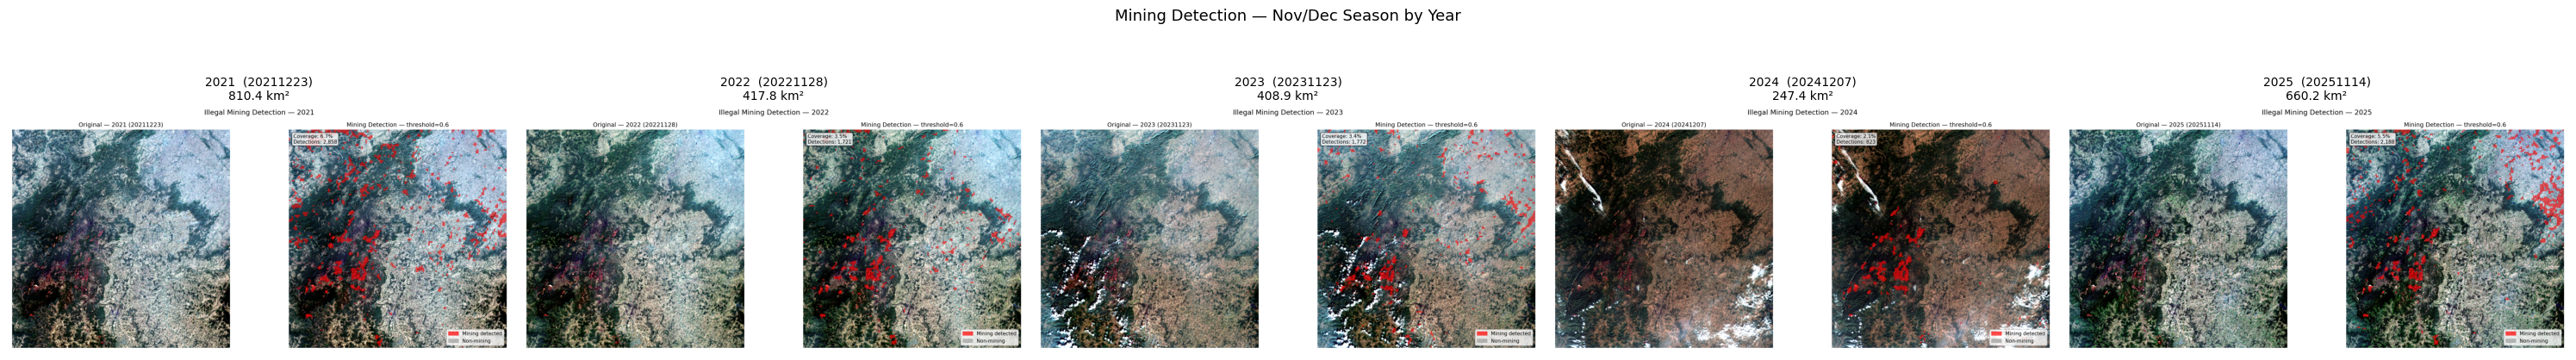

Saved: inference_output/temporal\all_years_overview.png


In [7]:
if yearly_results:
    n = len(yearly_results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1: axes = [axes]
    for ax, res in zip(axes, yearly_results):
        img_path = os.path.join(OUTPUT_DIR, f'{res["year"]}_overlay.png')
        if os.path.exists(img_path):
            ax.imshow(plt.imread(img_path))
            ax.set_title(f'{res["year"]}  ({res["date"]})\n{res["area_km2"]:.1f} km²', fontsize=10)
        ax.axis('off')
    plt.suptitle('Mining Detection — Nov/Dec Season by Year', fontsize=13)
    plt.tight_layout()
    out = os.path.join(OUTPUT_DIR, 'all_years_overview.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')